In [116]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt  
import seaborn as sns

In [117]:
file_path = r"F:\intern data sets\un supervised learning data\Forecasting data\Boys.xlsb"
file_path2 =r"F:\intern data sets\un supervised learning data\Additional data\boys data - additional months.xlsb"

In [118]:
boy_sales = pd.read_excel(file_path, sheet_name='Sale')
boy_sales_2 = pd.read_excel(file_path2, sheet_name = 'Sale')

In [119]:
print(boy_sales.shape)
print(boy_sales_2.shape)

(77643, 51)
(11794, 51)


In [120]:
df_sal = pd.concat([boy_sales, boy_sales_2], ignore_index=True)

In [121]:
zero_ratio = (df_sal['Qty'] == 0).mean()
print('Zero Percentage:', zero_ratio * 100)

Zero Percentage: 0.0


In [122]:
df_sal['Qty'].value_counts(normalize=True)

Qty
 1    0.972539
-1    0.022709
 2    0.004506
 3    0.000123
-2    0.000078
 4    0.000045
Name: proportion, dtype: float64

In [123]:
target_depts = ['KNIT TOP SETS', 'WOVEN TOP SETS']
df = df_sal[df_sal['Department'].isin(target_depts)].copy()
print("After dept filter:", df.shape)

After dept filter: (46038, 51)


In [124]:
df.head(3)

,Document Type,Month,Posting Date,Warehouse Name,Warehouse Code,Group Name,Division,Section,Department,Sku Code,...,Fabric Desc,Fabric Pattern,Length,Product Type,Division Group,Brand Type,Corrected Data,Qty,COST/PCS,Net Sale Value
0,Sales,OCTOBER,45937,TRICHY,TR,B-DW-KNIT TOP SETS,BOYS,DAILY WEAR,KNIT TOP SETS,BDKNBND9MRGNFDPRSSSHRNNC,...,NaN,PRINTS,SHORT,FASHION,BOYS,MARKET BRAND,BOYS$DAILY WEAR$KNIT TOP SETS$NA$NA$NA$0/M/14$...,1,190.90,360.00
1,Sales,OCTOBER,45937,AMBATTUR,AR,B-DW-KNIT TOP SETS,BOYS,DAILY WEAR,KNIT TOP SETS,BDKNBND1TRGNFDPRSSSHRNNC,...,NaN,PRINTS,SHORT,FASHION,BOYS,MARKET BRAND,BOYS$DAILY WEAR$KNIT TOP SETS$NA$NA$NA$2/XL/18...,1,186.75,355.01
2,Sales,OCTOBER,45937,TRICHY,TR,B-DW-KNIT TOP SETS,BOYS,DAILY WEAR,KNIT TOP SETS,BDKNBND2YRGNFDSTSSSHNNRC,...,NaN,STRIPE,SHORT,FASHION,BOYS,MARKET BRAND,BOYS$DAILY WEAR$KNIT TOP SETS$NA$NA$NA$3/2XL/2...,1,419.40,699.00


In [125]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 46038 entries, 0 to 89434
Data columns (total 51 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Document Type        46038 non-null  object 
 1   Month                46038 non-null  object 
 2   Posting Date         46038 non-null  int64  
 3   Warehouse Name       46038 non-null  object 
 4   Warehouse Code       46038 non-null  object 
 5   Group Name           46038 non-null  object 
 6   Division             46038 non-null  object 
 7   Section              46038 non-null  object 
 8   Department           46038 non-null  object 
 9   Sku Code             46038 non-null  object 
 10  Batch Number         46038 non-null  object 
 11  Batch System Number  46038 non-null  int64  
 12  Batch Abs Entry      46038 non-null  int64  
 13  Brand                46023 non-null  object 
 14  Style                46023 non-null  object 
 15  Shade                44186 non-null  obje

In [126]:
df.columns

Index(['Document Type', 'Month', 'Posting Date', 'Warehouse Name',
       'Warehouse Code', 'Group Name', 'Division', 'Section', 'Department',
       'Sku Code', 'Batch Number', 'Batch System Number', 'Batch Abs Entry',
       'Brand', 'Style', 'Shade', 'Size', 'Fit', 'Material', 'Mrp', 'Range',
       'Vendor code', 'Vendor Name', 'Batch Created Date',
       'Aging on Sale date', 'No Of Packs', 'Season', 'Agency', 'Top/Bottom',
       'Article Description', 'Category Desc', 'Mp', 'Vendor Color',
       'Vnh Color', 'Neck', 'Collar', 'Placket', 'Sleeve', 'Pocket', 'Fabrics',
       'Fabric Type', 'Fabric Desc', 'Fabric Pattern', 'Length',
       'Product Type', 'Division Group', 'Brand Type', 'Corrected Data', 'Qty',
       'COST/PCS', 'Net Sale Value'],
      dtype='object')

In [127]:
print(dict(df.dtypes))

{'Document Type': dtype('O'), 'Month': dtype('O'), 'Posting Date': dtype('int64'), 'Warehouse Name': dtype('O'), 'Warehouse Code': dtype('O'), 'Group Name': dtype('O'), 'Division': dtype('O'), 'Section': dtype('O'), 'Department': dtype('O'), 'Sku Code': dtype('O'), 'Batch Number': dtype('O'), 'Batch System Number': dtype('int64'), 'Batch Abs Entry': dtype('int64'), 'Brand': dtype('O'), 'Style': dtype('O'), 'Shade': dtype('O'), 'Size': dtype('O'), 'Fit': dtype('O'), 'Material': dtype('O'), 'Mrp': dtype('float64'), 'Range': dtype('O'), 'Vendor code': dtype('O'), 'Vendor Name': dtype('O'), 'Batch Created Date': dtype('int64'), 'Aging on Sale date': dtype('float64'), 'No Of Packs': dtype('float64'), 'Season': dtype('O'), 'Agency': dtype('float64'), 'Top/Bottom': dtype('float64'), 'Article Description': dtype('O'), 'Category Desc': dtype('O'), 'Mp': dtype('O'), 'Vendor Color': dtype('O'), 'Vnh Color': dtype('O'), 'Neck': dtype('O'), 'Collar': dtype('O'), 'Placket': dtype('O'), 'Sleeve': dty

In [128]:
df.columns = df_sal.columns.str.strip().str.lower().str.replace(' ', '_')


In [129]:
df['posting_date'] = pd.to_datetime(df['posting_date'],unit='D', origin='1899-12-30')
df['batch_created_date'] = pd.to_datetime(df['batch_created_date'],unit='D', origin='1899-12-30')

In [130]:
df['posting_date'].isnull().sum()

np.int64(0)

In [131]:


df['batch_created_date'].isnull().sum()

np.int64(0)

In [132]:
null_counts = df.isnull().sum()
null_counts = null_counts[null_counts > 0].sort_values(ascending=False)
print(dict(null_counts))

{'no_of_packs': np.int64(46038), 'agency': np.int64(46038), 'top/bottom': np.int64(46038), 'fabric_desc': np.int64(46038), 'placket': np.int64(45571), 'category_desc': np.int64(44782), 'pocket': np.int64(37997), 'mp': np.int64(35838), 'collar': np.int64(30473), 'article_description': np.int64(24631), 'neck': np.int64(21245), 'vnh_color': np.int64(9954), 'vendor_color': np.int64(8981), 'fabrics': np.int64(8792), 'fabric_type': np.int64(6793), 'fabric_pattern': np.int64(6127), 'material': np.int64(1920), 'shade': np.int64(1852), 'season': np.int64(1008), 'fit': np.int64(505), 'range': np.int64(21), 'brand': np.int64(15), 'vendor_code': np.int64(15), 'vendor_name': np.int64(15), 'style': np.int64(15), 'aging_on_sale_date': np.int64(6)}


In [133]:
print("\nUnique Departments:")
print(df['department'].value_counts())

print("\nUnique Sleeve:")
print(df['sleeve'].value_counts())

print("\nUnique Length:")
print(df['length'].value_counts())

print("\nUnique Range:")
print(df['range'].value_counts())


Unique Departments:
department
KNIT TOP SETS     30578
WOVEN TOP SETS    15460
Name: count, dtype: int64

Unique Sleeve:
sleeve
SHORT SLEEVE    32831
FULL SLEEVE      9824
SLEEVE LESS      3181
CAP SLEEVE        108
Full Sleeve        58
Short Sleeve       36
Name: count, dtype: int64

Unique Length:
length
SHORT                  28850
FULL LENGTH             9947
REGULAR                 6860
ABOVE KNEE (1/2)         170
CALF LENGTH (3/4TH)       77
Full Length               58
Regular                   36
MINI                      22
KNEE LENGTH               10
CROP                       8
Name: count, dtype: int64

Unique Range:
range
401-700      14395
200-400      10254
701-1050      9726
1201-1650     3507
600-1200      3267
1651-2200     1846
1051-2500     1651
2201-3400     1371
Name: count, dtype: int64


In [134]:
print("\nMin value:", df['posting_date'].min())
print("Max value:", df['posting_date'].max())


Min value: 2024-03-01 00:00:00
Max value: 2025-11-17 00:00:00


In [135]:
print("Min:", df['batch_created_date'].min(), " Max:", df['batch_created_date'].max())

Min: 2015-09-01 00:00:00  Max: 2025-10-29 00:00:00


In [136]:
df['department'].value_counts()

department
KNIT TOP SETS     30578
WOVEN TOP SETS    15460
Name: count, dtype: int64

In [137]:

df['sleeve'] = df['sleeve'].str.strip().str.upper()

In [138]:
df['sleeve'] = df['sleeve'].apply(lambda x: 'Full Sleeve' if x == 'FULL SLEEVE' else 'Sleeve Less' if x == 'SLEEVE LESS' else 'Short Sleeve')

In [139]:
print(df['sleeve'].value_counts())
print(df['sleeve'].isnull().sum())

sleeve
Short Sleeve    32975
Full Sleeve      9882
Sleeve Less      3181
Name: count, dtype: int64
0


In [140]:
df['length'] = df['length'].str.strip().str.upper()

In [141]:
df['length'] = df['length'].apply(lambda x: 'FULL LENGTH' if x == 'FULL LENGTH' else 'HALF LENGTH')

In [142]:
df_clean = df.copy()

In [143]:
df_clean['sleeve'].value_counts()

sleeve
Short Sleeve    32975
Full Sleeve      9882
Sleeve Less      3181
Name: count, dtype: int64

In [144]:
df_clean = df[['department','posting_date',
         'size',
         'mrp',
         'range','warehouse_code',
         'batch_created_date',
         'aging_on_sale_date',
         'sleeve',
         'length',
         'qty',
         'net_sale_value']]

In [145]:
df_clean.shape

(46038, 12)

In [146]:
df_clean.columns

Index(['department', 'posting_date', 'size', 'mrp', 'range', 'warehouse_code',
       'batch_created_date', 'aging_on_sale_date', 'sleeve', 'length', 'qty',
       'net_sale_value'],
      dtype='object')

EDA PERFORMING

In [147]:
df_clean['sleeve'].value_counts()


sleeve
Short Sleeve    32975
Full Sleeve      9882
Sleeve Less      3181
Name: count, dtype: int64

In [148]:
df_clean['length'].value_counts()

length
HALF LENGTH    36033
FULL LENGTH    10005
Name: count, dtype: int64

In [149]:
df_clean['warehouse_code'].value_counts()

warehouse_code
TN       18372
AS        5058
TM        4488
TR        2671
AR        2377
AN        2133
VA        2108
MP        1790
MW        1620
CB        1525
VC        1479
MA         745
SB         679
VP         477
NLKMC      305
AD          99
NL          66
ER          41
TI           3
TJ           2
Name: count, dtype: int64

In [150]:
df_clean.isnull().sum()

department             0
posting_date           0
size                   0
mrp                    0
range                 21
warehouse_code         0
batch_created_date     0
aging_on_sale_date     6
sleeve                 0
length                 0
qty                    0
net_sale_value         0
dtype: int64

In [151]:
df_clean['qty'].value_counts()

qty
 1    44855
-1      983
 2      197
-2        1
 3        1
 4        1
Name: count, dtype: int64

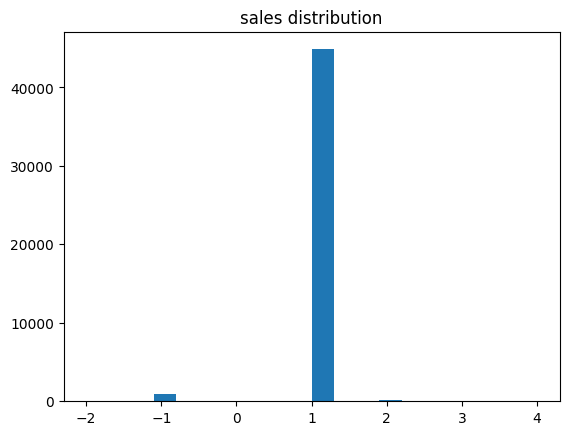

In [152]:
import matplotlib.pyplot as plt

plt.hist(df_clean['qty'],bins=20)
plt.title('sales distribution')
plt.show()

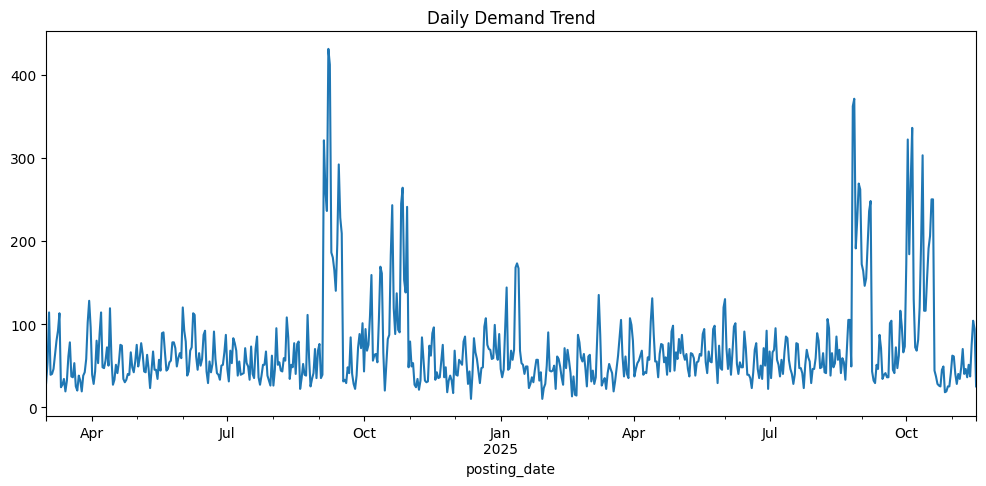

In [153]:
daily_sales = df_clean.groupby('posting_date')['qty'].sum()

daily_sales.plot(figsize=(12,5))
plt.title("Daily Demand Trend")
plt.show()

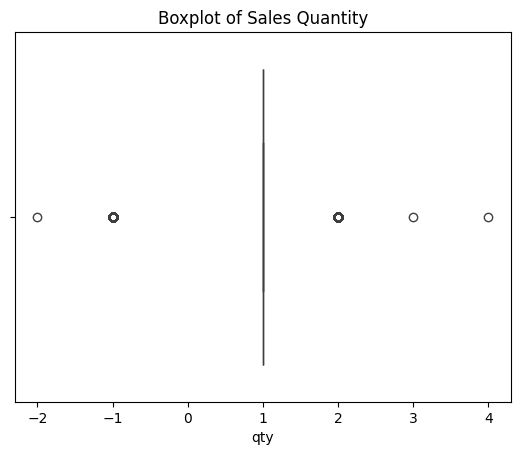

In [154]:

sns.boxplot(x=df_clean['qty'])
plt.title('Boxplot of Sales Quantity')
plt.show()

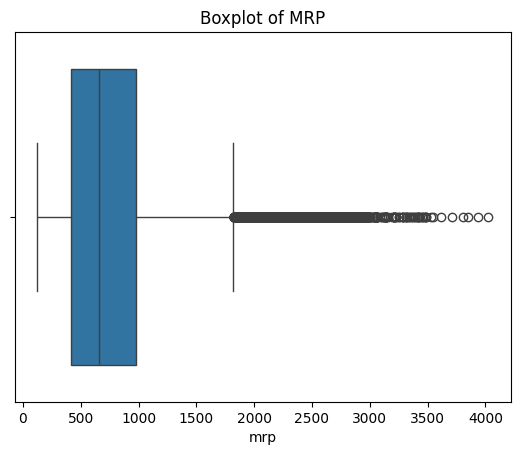

In [155]:
sns.boxplot(x=df_clean['mrp'])
plt.title('Boxplot of MRP')
plt.show()

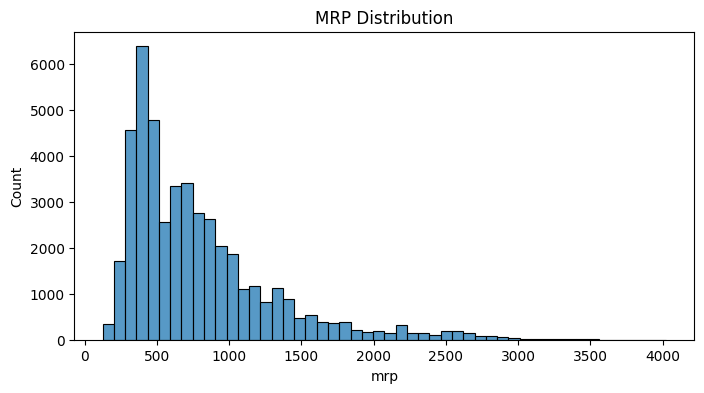

In [156]:
plt.figure(figsize=(8,4))
sns.histplot(df_clean['mrp'], bins=50)
plt.title("MRP Distribution")
plt.show()

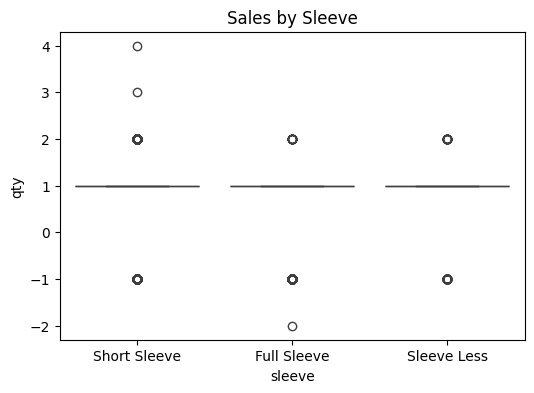

In [157]:
plt.figure(figsize=(6,4))
sns.boxplot(x='sleeve', y='qty', data=df_clean)
plt.title("Sales by Sleeve")
plt.show()

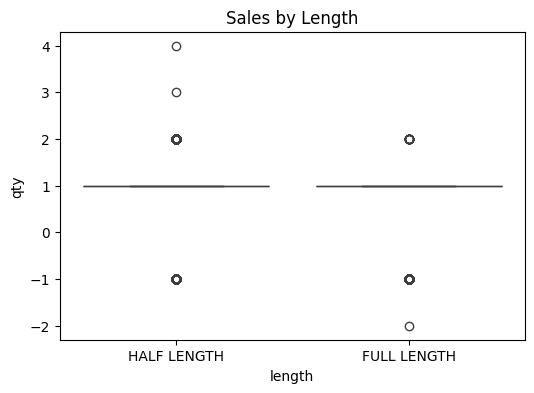

In [158]:
plt.figure(figsize=(6,4))
sns.boxplot(x='length', y='qty', data=df_clean)
plt.title("Sales by Length")
plt.show()

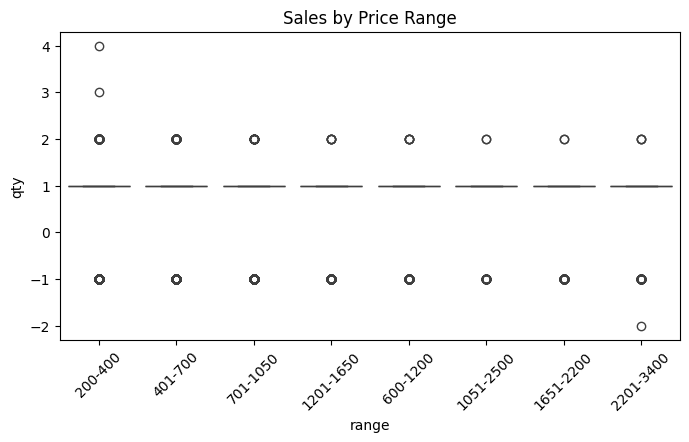

In [159]:
plt.figure(figsize=(8,4))
sns.boxplot(x='range', y='qty', data=df_clean)
plt.xticks(rotation=45)
plt.title("Sales by Price Range")
plt.show()

In [160]:
df_clean = df_clean[(df_clean['qty'] > 0) & (df_clean['net_sale_value'] > 0)]

In [161]:
print("Remaining shape:", df_clean.shape)

print("Negative Qty remaining:", (df_clean['qty'] < 0).sum())
print("Negative Net Sales remaining:", (df_clean['net_sale_value'] < 0).sum())

Remaining shape: (45044, 12)
Negative Qty remaining: 0
Negative Net Sales remaining: 0


In [162]:
df_clean = df_clean.reset_index(drop=True)

In [163]:
df_clean["selling_price"] = df_clean["net_sale_value"] / df_clean["qty"]

df_clean["discount_value"] = df_clean["mrp"] - df_clean["selling_price"]

df_clean["discount_pct"] = df_clean["discount_value"] / df_clean["mrp"]

df_clean["price_gap"] = df_clean["discount_value"]

In [164]:
print(df_clean[['mrp','selling_price','discount_pct','price_gap']].head())

     mrp  selling_price  discount_pct  price_gap
0  360.0         360.00      0.000000       0.00
1  355.0         355.01     -0.000028      -0.01
2  699.0         699.00      0.000000       0.00
3  569.0         569.00      0.000000       0.00
4  569.0         569.00      0.000000       0.00


In [165]:
df_clean['discount_pct'] = df_clean['discount_pct'].clip(lower=0)

In [166]:
print(df_clean['discount_pct'].describe())

count    45044.000000
mean         0.052146
std          0.119278
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          0.917431
Name: discount_pct, dtype: float64


In [167]:
df_clean['range'].value_counts()

range
401-700      14158
200-400      10088
701-1050      9539
1201-1650     3393
600-1200      3167
1651-2200     1759
1051-2500     1610
2201-3400     1310
Name: count, dtype: int64

In [168]:
print(df_clean['mrp'].min(), df_clean['mrp'].max())

125.0 4025.0


In [169]:
df_clean['range'].isnull().sum()

np.int64(20)

In [170]:
df_clean['range'] = df_clean['range'].fillna(df_clean['range'].mode()[0])

In [171]:
bins = [0,200,400,700,1050,1650,2200,3400,4500]

labels = [
'0-200',
'200-400',
'401-700',
'701-1050',
'1051-1650',
'1651-2200',
'2201-3400',
'3401-4500'
]

df_clean['range'] = pd.cut(df_clean['mrp'], bins=bins, labels=labels)

In [172]:
df_clean['range'] = pd.Categorical(
    df_clean['range'],
    categories=labels,
    ordered=True
)

In [173]:
df_clean['range'].value_counts().sort_index()

range
0-200          325
200-400      10205
401-700      14366
701-1050     10756
1051-1650     6317
1651-2200     1731
2201-3400     1324
3401-4500       20
Name: count, dtype: int64

In [174]:
df_clean.columns

Index(['department', 'posting_date', 'size', 'mrp', 'range', 'warehouse_code',
       'batch_created_date', 'aging_on_sale_date', 'sleeve', 'length', 'qty',
       'net_sale_value', 'selling_price', 'discount_value', 'discount_pct',
       'price_gap'],
      dtype='object')

In [175]:
df_clean['month'] = df_clean['posting_date'].dt.month
df_clean['week'] = df_clean['posting_date'].dt.isocalendar().week
df_clean['day_of_week'] = df_clean['posting_date'].dt.dayofweek
df_clean['is_weekend'] = (df_clean['day_of_week'] >= 5).astype(int)

In [176]:
df_clean['product_age'] = (
    df_clean['posting_date'] - df_clean['batch_created_date']
).dt.days

In [177]:
df_clean['week_start_date'] = df_clean['posting_date'] - pd.to_timedelta(
    df_clean['posting_date'].dt.weekday, unit='D'
)

In [178]:
df_clean['product_age_week'] = df_clean['product_age'] // 7

In [179]:
df_clean.columns

Index(['department', 'posting_date', 'size', 'mrp', 'range', 'warehouse_code',
       'batch_created_date', 'aging_on_sale_date', 'sleeve', 'length', 'qty',
       'net_sale_value', 'selling_price', 'discount_value', 'discount_pct',
       'price_gap', 'month', 'week', 'day_of_week', 'is_weekend',
       'product_age', 'week_start_date', 'product_age_week'],
      dtype='object')

In [363]:
df_group = df_clean.copy()

In [364]:
df_group.columns

Index(['department', 'posting_date', 'size', 'mrp', 'range', 'warehouse_code',
       'batch_created_date', 'aging_on_sale_date', 'sleeve', 'length', 'qty',
       'net_sale_value', 'selling_price', 'discount_value', 'discount_pct',
       'price_gap', 'month', 'week', 'day_of_week', 'is_weekend',
       'product_age', 'week_start_date', 'product_age_week'],
      dtype='object')

In [365]:
df_group = df_group.drop(columns=[
'selling_price',
'discount_value',
'price_gap',
'batch_created_date',
'aging_on_sale_date',
'product_age'
])

In [366]:
weekly_data = df_group.groupby(
[
'week_start_date',
'department',
'size',
'sleeve',
'length',
'range'
]
).agg({
'qty':'sum',
'mrp':'mean',
'discount_pct':'mean',
'product_age_week':'mean'
}).reset_index()

C:\Users\DINESHWAR\AppData\Local\Temp\ipykernel_9236\1926129799.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  weekly_data = df_group.groupby(


In [367]:
df_group.columns

Index(['department', 'posting_date', 'size', 'mrp', 'range', 'warehouse_code',
       'sleeve', 'length', 'qty', 'net_sale_value', 'discount_pct', 'month',
       'week', 'day_of_week', 'is_weekend', 'week_start_date',
       'product_age_week'],
      dtype='object')

In [368]:
weekly_data['series_id'] = (
    weekly_data['department'].astype(str) + "_" +
    weekly_data['size'].astype(str) + "_" +
    weekly_data['sleeve'].astype(str) + "_" +
    weekly_data['length'].astype(str) + "_" +
    weekly_data['range'].astype(str)
)

In [369]:
import pandas as pd

all_weeks = pd.date_range(
    weekly_data['week_start_date'].min(),
    weekly_data['week_start_date'].max(),
    freq='W-MON'
)

series = weekly_data['series_id'].unique()

full_index = pd.MultiIndex.from_product(
    [series, all_weeks],
    names=['series_id','week_start_date']
)

weekly_full = weekly_data.set_index(
    ['series_id','week_start_date']
).reindex(full_index).reset_index()

weekly_full['qty'] = weekly_full['qty'].fillna(0)

In [370]:
series_info = weekly_data.drop_duplicates('series_id')[
['series_id','department','size','sleeve','length','range']
]

weekly_full = weekly_full.merge(series_info, on='series_id', how='left')

In [371]:
weekly_full = weekly_full.sort_values(['series_id','week_start_date'])

weekly_full['lag_1'] = weekly_full.groupby('series_id')['qty'].shift(1)
weekly_full['lag_2'] = weekly_full.groupby('series_id')['qty'].shift(2)
weekly_full['lag_4'] = weekly_full.groupby('series_id')['qty'].shift(4)

In [372]:
weekly_full['rolling_mean_4'] = (
    weekly_full.groupby('series_id')['qty']
    .shift(1)
    .rolling(4)
    .mean()
)

In [373]:
weekly_full['momentum_4'] = weekly_full['lag_1'] - weekly_full['lag_4']

In [374]:
events = [
    {"Event": "Womens_Day", "From": "2024-03-08", "To": "2024-03-10"},
    {"Event": "Anniversary_Sale", "From": "2024-09-04", "To": "2024-09-16"},
    {"Event": "Diwali", "From": "2024-10-08", "To": "2024-10-31"},
    {"Event": "Womens_Day", "From": "2025-03-07", "To": "2025-03-09"},
    {"Event": "Anniversary_Sale", "From": "2025-08-26", "To": "2025-09-07"},
    {"Event": "Diwali", "From": "2025-09-27", "To": "2025-10-20"}
]

events_df = pd.DataFrame(events)

events_df['From'] = pd.to_datetime(events_df['From'])
events_df['To'] = pd.to_datetime(events_df['To'])

weekly_full['event_flag'] = 0

for _, row in events_df.iterrows():
    mask = (
        (weekly_full['week_start_date'] >= row['From']) &
        (weekly_full['week_start_date'] <= row['To'])
    )
    weekly_full.loc[mask,'event_flag'] = 1

In [375]:
weekly_full['week_of_year'] = weekly_full['week_start_date'].dt.isocalendar().week.astype(int)

weekly_full['sin_week'] = np.sin(2*np.pi*weekly_full['week_of_year']/52)

weekly_full['cos_week'] = np.cos(2*np.pi*weekly_full['week_of_year']/52)

In [376]:
weekly_full['rolling_mean_8'] = (
    weekly_full.groupby('series_id')['qty']
    .shift(1)
    .rolling(8)
    .mean()
)

In [377]:
weekly_full["series_avg_sales"] = (
    weekly_full.groupby("series_id")["qty"]
    .transform("mean")
)

In [378]:
weekly_full["qty"].value_counts().head(10)

qty
0    139489
1      3278
2      1510
3       934
4       607
5       440
6       343
7       247
8       214
9       162
Name: count, dtype: int64

In [379]:
weekly_full["demand_flag"] = (weekly_full["qty"] > 0).astype(int)

In [380]:
weekly_data = weekly_data.dropna().reset_index(drop=True)

In [381]:
weekly_full = weekly_full.rename(columns={
'department_x':'department',
'size_x':'size',
'sleeve_x':'sleeve',
'length_x':'length',
'range_x':'range'
})

In [382]:
weekly_full = weekly_full.rename(columns={
'department_x':'department',
'size_x':'size',
'sleeve_x':'sleeve',
'length_x':'length',
'range_x':'range'
})

In [383]:
from sklearn.preprocessing import LabelEncoder

cat_cols = ['department','size','sleeve','length','range']

encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    weekly_full[col] = le.fit_transform(weekly_full[col].astype(str))
    encoders[col] = le

In [384]:
weekly_full.columns

Index(['series_id', 'week_start_date', 'department', 'size', 'sleeve',
       'length', 'range', 'qty', 'mrp', 'discount_pct', 'product_age_week',
       'department_y', 'size_y', 'sleeve_y', 'length_y', 'range_y', 'lag_1',
       'lag_2', 'lag_4', 'rolling_mean_4', 'momentum_4', 'event_flag',
       'week_of_year', 'sin_week', 'cos_week', 'rolling_mean_8',
       'series_avg_sales', 'demand_flag'],
      dtype='object')

In [385]:
split_date = weekly_full["week_start_date"].quantile(0.8)

train = weekly_full[weekly_full["week_start_date"] <= split_date].copy()
test  = weekly_full[weekly_full["week_start_date"] > split_date].copy()

In [386]:
y_train = train["qty"]
y_test  = test["qty"]

In [387]:
clf_features = [
'department',
'size',
'sleeve',
'length',
'range',
'product_age_week',
'event_flag',
'sin_week',
'cos_week',
'lag_1',
'lag_2'
]

In [388]:
reg_features = [
'department',
'size',
'sleeve',
'length',
'range',
'mrp',
'discount_pct',
'product_age_week',
'lag_1',
'lag_2',
'lag_4',
'rolling_mean_4',
'rolling_mean_8',
'momentum_4',
'sin_week',
'cos_week'
]

In [389]:
X_train_clf = train[clf_features]
X_test_clf  = test[clf_features]

y_train_clf = train["demand_flag"]
y_test_clf  = test["demand_flag"]

In [390]:
train_nonzero = train[train["qty"] > 0]

X_train_reg = train_nonzero[reg_features]
y_train_reg = train_nonzero["qty"]

X_test_reg = test[reg_features]

In [391]:
from lightgbm import LGBMClassifier

clf = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    random_state=42
)

clf.fit(X_train_clf, y_train_clf)

[LightGBM] [Info] Number of positive: 7321, number of negative: 111815
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007668 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 469
[LightGBM] [Info] Number of data points in the train set: 119136, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.061451 -> initscore=-2.726099
[LightGBM] [Info] Start training from score -2.726099
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gai

LGBMClassifier(learning_rate=0.05, max_depth=8, n_estimators=500,
               random_state=42)

In [392]:
demand_prob = clf.predict_proba(X_test_clf)[:,1]

In [393]:
from lightgbm import LGBMRegressor

reg = LGBMRegressor(
    n_estimators=800,
    learning_rate=0.03,
    max_depth=10,
    num_leaves=50,
    random_state=42
)

reg.fit(X_train_reg, y_train_reg)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.019247 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1417
[LightGBM] [Info] Number of data points in the train set: 7321, number of used features: 16
[LightGBM] [Info] Start training from score 4.608660
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

LGBMRegressor(learning_rate=0.03, max_depth=10, n_estimators=800, num_leaves=50,
              random_state=42)

In [394]:
size_pred = reg.predict(X_test_reg)

In [395]:
import numpy as np

final_pred = demand_prob * size_pred

In [396]:
wape = np.sum(np.abs(y_test - final_pred)) / np.sum(y_test)

print("Two-Stage Model WAPE:", wape * 100)

Two-Stage Model WAPE: 55.348811762886385


In [ ]:
from lightgbm import LGBMClassifier

clf = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    random_state=42
)

clf.fit(train[clf_features], train["demand_flag"])

In [ ]:
demand_prob = clf.predict_proba(test[clf_features])[:,1]

In [320]:
'''split_index = int(len(weekly_full)*0.8)

train = weekly_full.iloc[:split_index]
test = weekly_full.iloc[split_index:]

X_train = train[features].astype(float)
X_test = test[features].astype(float)

y_train = train['qty']
y_test = test['qty']'''

"split_index = int(len(weekly_full)*0.8)\n\ntrain = weekly_full.iloc[:split_index]\ntest = weekly_full.iloc[split_index:]\n\nX_train = train[features].astype(float)\nX_test = test[features].astype(float)\n\ny_train = train['qty']\ny_test = test['qty']"

In [ ]:
'''plit_date = weekly_full['week_start_date'].quantile(0.8)

train = weekly_full[weekly_full['week_start_date'] <= split_date]
test = weekly_full[weekly_full['week_start_date'] > split_date]

X_train = train[features]
X_test = test[features]

y_train = train['qty']
y_test = test['qty']'''

In [354]:

from lightgbm import LGBMClassifier

clf = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    random_state=42
)

clf.fit(X_train, train["demand_flag"])

[LightGBM] [Info] Number of positive: 7321, number of negative: 111815
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006901 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1420
[LightGBM] [Info] Number of data points in the train set: 119136, number of used features: 17
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.061451 -> initscore=-2.726099
[LightGBM] [Info] Start training from score -2.726099
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

LGBMClassifier(learning_rate=0.05, max_depth=8, n_estimators=500,
               random_state=42)

In [355]:
demand_prob = clf.predict_proba(X_test)[:,1]

In [356]:
train_nonzero = train[train["log_qty"] > 0]

X_train_reg = train_nonzero[features]
y_train_reg = train_nonzero["log_qty"]

In [357]:
from lightgbm import LGBMRegressor

reg = LGBMRegressor(
    n_estimators=800,
    learning_rate=0.03,
    max_depth=10,
    num_leaves=50,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

reg.fit(X_train_reg, y_train_reg)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.113719 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1419
[LightGBM] [Info] Number of data points in the train set: 7321, number of used features: 17
[LightGBM] [Info] Start training from score 1.377954
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: 

LGBMRegressor(colsample_bytree=0.8, learning_rate=0.03, max_depth=10,
              n_estimators=800, num_leaves=50, random_state=42, subsample=0.8)

In [358]:
size_pred = reg.predict(X_test)

In [359]:
import numpy as np

final_pred = demand_prob * size_pred

In [360]:
wape = np.sum(np.abs(y_test - final_pred)) / np.sum(y_test)

print("Two-Stage Model WAPE:", wape * 100)

Two-Stage Model WAPE: 78.25375525670275


In [361]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(test["demand_flag"], demand_prob)

print("Demand Occurrence AUC:", auc)

Demand Occurrence AUC: 1.0


In [326]:
wape = np.sum(np.abs(y_test - ensemble_pred)) / np.sum(y_test)

print("Ensemble WAPE:", wape * 100)

Ensemble WAPE: 52.829153515426974


In [327]:
wape_lgb = np.sum(np.abs(y_test - lgb_pred)) / np.sum(y_test)
wape_xgb = np.sum(np.abs(y_test - xgb_pred)) / np.sum(y_test)

print("LightGBM WAPE:", wape_lgb * 100)
print("XGBoost WAPE:", wape_xgb * 100)

LightGBM WAPE: 53.40907064318533
XGBoost WAPE: 52.941325756998346


In [328]:
import pandas as pd

fi = pd.DataFrame({
    "feature": X_train.columns,
    "importance": lgb_model.feature_importances_
}).sort_values(by="importance", ascending=False)

print(fi)

             feature  importance
7   product_age_week        2797
11    rolling_mean_4        2728
12    rolling_mean_8        2544
5                mrp        2379
6       discount_pct        2089
8              lag_1        2049
14  series_avg_sales        1725
13        momentum_4        1646
9              lag_2        1563
16          sin_week        1534
17          cos_week        1440
10             lag_4        1115
1               size         616
4              range         126
15        event_flag         102
2             sleeve          63
0         department          54
3             length          26


In [ ]:
df_group = df_clean.copy()

In [ ]:
weekly_data = weekly_data[weekly_data['qty'] > 0].reset_index(drop=True)

In [ ]:
print(weekly_data.isnull().sum())

week_start_date     0
department          0
size                0
sleeve              0
length              0
range               0
qty                 0
mrp                 0
discount_pct        0
product_age_week    0
dtype: int64


In [ ]:
weekly_data.shape

(9023, 10)

In [ ]:
weekly_data['series_id'] = (
    weekly_data['department'].astype(str) + "_" +
    weekly_data['size'].astype(str) + "_" +
    weekly_data['sleeve'].astype(str) + "_" +
    weekly_data['length'].astype(str) + "_" +
    weekly_data['range'].astype(str)
)

In [ ]:
print("Number of series:", weekly_data['series_id'].nunique())

Number of series: 332


In [ ]:
weekly_data = weekly_data.sort_values(['series_id','week_start_date'])

In [ ]:
weekly_data['lag_1'] = weekly_data.groupby('series_id')['qty'].shift(1)
weekly_data['lag_2'] = weekly_data.groupby('series_id')['qty'].shift(2)
weekly_data['lag_4'] = weekly_data.groupby('series_id')['qty'].shift(4)

In [ ]:
weekly_data['rolling_mean_4'] = (
    weekly_data.groupby('series_id')['qty']
    .shift(1)
    .rolling(4)
    .mean()
)

In [ ]:
weekly_data['momentum_4'] = weekly_data['lag_1'] - weekly_data['lag_4']

In [ ]:
print(weekly_data.isnull().sum())

week_start_date        0
department             0
size                   0
sleeve                 0
length                 0
range                  0
qty                    0
mrp                    0
discount_pct           0
product_age_week       0
series_id              0
lag_1                332
lag_2                614
lag_4               1100
rolling_mean_4      1100
momentum_4          1100
dtype: int64


In [ ]:
weekly_data = weekly_data.dropna().reset_index(drop=True)

In [ ]:
print(weekly_data.shape)
print(weekly_data.head())
weekly_data[['lag_1','lag_2','lag_4','rolling_mean_4','momentum_4']].head()

(7923, 16)
  week_start_date     department    size       sleeve       length      range  \
0      2024-05-20  KNIT TOP SETS  0/M/14  Full Sleeve  FULL LENGTH  1051-1650   
1      2024-06-17  KNIT TOP SETS  0/M/14  Full Sleeve  FULL LENGTH  1051-1650   
2      2024-06-24  KNIT TOP SETS  0/M/14  Full Sleeve  FULL LENGTH  1051-1650   
3      2024-07-08  KNIT TOP SETS  0/M/14  Full Sleeve  FULL LENGTH  1051-1650   
4      2024-07-22  KNIT TOP SETS  0/M/14  Full Sleeve  FULL LENGTH  1051-1650   

   qty     mrp  discount_pct  product_age_week  \
0    1  1195.0           0.0              21.0   
1    1  1245.0           0.0              25.0   
2    1  1165.0           0.0              14.0   
3    1  1445.0           0.0              28.0   
4    2  1195.0           0.0              30.0   

                                           series_id  lag_1  lag_2  lag_4  \
0  KNIT TOP SETS_0/M/14_Full Sleeve_FULL LENGTH_1...    1.0    1.0    1.0   
1  KNIT TOP SETS_0/M/14_Full Sleeve_FULL LENGTH

,lag_1,lag_2,lag_4,rolling_mean_4,momentum_4
0,1.0,1.0,1.0,1.0,0.0
1,1.0,1.0,1.0,1.0,0.0
2,1.0,1.0,1.0,1.0,0.0
3,1.0,1.0,1.0,1.0,0.0
4,1.0,1.0,1.0,1.0,0.0


In [ ]:
weekly_data['attributes_sales_mean'] = (
    weekly_data.groupby(['department','size','sleeve','length','range'])['qty']
    .transform('mean')
)

C:\Users\DINESHWAR\AppData\Local\Temp\ipykernel_18768\4091259640.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  weekly_data.groupby(['department','size','sleeve','length','range'])['qty']


In [ ]:
weekly_data['department_sales_mean'] = (
    weekly_data.groupby('department')['qty']
    .transform('mean')
)

In [ ]:
from sklearn.preprocessing import LabelEncoder

cat_cols = ['department','size','sleeve','length','range']

encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    weekly_data[col] = le.fit_transform(weekly_data[col])
    encoders[col] = le

In [ ]:
features = [
'department','size','sleeve','length','range',
'mrp','discount_pct','product_age_week',
'lag_1','lag_2','lag_4','rolling_mean_4','momentum_4',
'attributes_sales_mean','department_sales_mean'
]

X = weekly_data[features]
y = weekly_data['qty']

In [ ]:
pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, pred)

print("MAE:", mae)

MAE: 3.71071675742056


In [ ]:
import pandas as pd

feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.feature_importances_
}).sort_values(by='importance', ascending=False)

print(feature_importance)

                  feature  importance
7        product_age_week        1659
11         rolling_mean_4        1552
6            discount_pct        1533
5                     mrp        1361
8                   lag_1        1096
13  attributes_sales_mean         985
9                   lag_2         868
12             momentum_4         834
10                  lag_4         726
1                    size         442
4                   range          94
2                  sleeve          39
0              department          30
3                  length           5
14  department_sales_mean           0


In [ ]:
import numpy as np

wape = np.sum(np.abs(y_test - pred)) / np.sum(y_test)

print("WAPE:", wape*100)

WAPE: 52.753000631194524


In [425]:
df1 = df_group.copy()

df1 = df1[df1['qty'] > 0].reset_index(drop=True)

In [426]:
df1.columns

Index(['department', 'posting_date', 'size', 'mrp', 'range', 'warehouse_code',
       'sleeve', 'length', 'qty', 'net_sale_value', 'discount_pct', 'month',
       'week', 'day_of_week', 'is_weekend', 'week_start_date',
       'product_age_week'],
      dtype='object')

In [427]:
df1 = df1.reset_index(drop=True)

In [428]:
df1["week_start_date"] = pd.to_datetime(df1["week_start_date"])

In [429]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.ensemble import (
    GradientBoostingRegressor,
    RandomForestRegressor,
    HistGradientBoostingRegressor,
    ExtraTreesRegressor,
)

In [430]:
try:
    import xgboost as xgb
    HAS_XGB = True
except:
    HAS_XGB = False

try:
    import lightgbm as lgb
    HAS_LGB = True
except:
    HAS_LGB = False

In [431]:
def build_grouped_dataset(df):
    df = df.copy()
    df = df.reset_index(drop=True)

    group_keys = [
        "week_start_date",
        "department",
        "sleeve",
        "length",
        "range",
        "size",
        "warehouse_code"
    ]

    agg_dict = {
        "qty": "sum",
        "net_sale_value": "sum",
        "mrp": "mean",
        "product_age_week": "mean",
        "month": "first",
        "week": "first",
        "day_of_week": "mean",
        "is_weekend": "mean"
    }

    df_agg = (
        df.groupby(group_keys)
        .agg(agg_dict)
        .reset_index()
    )
    df_agg.rename(columns={"qty": "weekly_qty"}, inplace=True)
    df_agg = df_agg.sort_values(
        ["department","sleeve","length","range","size","week_start_date"]
    )

    print("Grouped dataset shape:", df_agg.shape)

    return df_agg

In [432]:
def engineer_features(df):

    df = df.copy()

    df["selling_price"] = (
        df["net_sale_value"] / df["weekly_qty"].replace(0, np.nan)
    ).fillna(df["mrp"])

    df["discount_pct"] = (
        (df["mrp"] - df["selling_price"]) /
        df["mrp"].replace(0, np.nan)
    ).fillna(0)

    df["price_bucket"] = pd.qcut(
        df["mrp"],
        q=5,
        labels=False,
        duplicates="drop"
    ).fillna(0)

    df["quarter"] = df["week_start_date"].dt.quarter
    df["year"] = df["week_start_date"].dt.year

    df["sku_key"] = (
        df["department"].astype(str) + "_" +
        df["sleeve"].astype(str) + "_" +
        df["length"].astype(str) + "_" +
        df["range"].astype(str) + "_" +
        df["size"].astype(str)
    )

    g = df.groupby("sku_key")["weekly_qty"]

    df["lag_1"] = g.shift(1)
    df["lag_2"] = g.shift(2)
    df["lag_4"] = g.shift(4)

    df["rolling_mean_2"] = g.shift(1).rolling(2).mean()
    df["rolling_mean_4"] = g.shift(1).rolling(4).mean()

    df["rolling_std_2"] = g.shift(1).rolling(2).std()

    df["momentum"] = df["lag_1"] - df["lag_2"]

    df["attributes_sales_mean"] = df.groupby(
        ["sleeve","length","range"]
    )["weekly_qty"].transform("mean")

    df["department_sales_mean"] = df.groupby(
        "department"
    )["weekly_qty"].transform("mean")

    df["warehouse_avg_sales"] = df.groupby(
        "warehouse_code"
    )["weekly_qty"].transform("mean")

    df["size_sales_mean"] = df.groupby(
        "size"
    )["weekly_qty"].transform("mean")

    from sklearn.preprocessing import LabelEncoder

    cat_cols = [
        "department",
        "sleeve",
        "length",
        "range",
        "size",
        "warehouse_code"
    ]

    for c in cat_cols:
        le = LabelEncoder()
        df[c+"_enc"] = le.fit_transform(df[c].astype(str))

    print("Feature dataset shape:", df.shape)

    return df

In [420]:
FEATURE_COLS = [

    "department_enc",
    "sleeve_enc",
    "length_enc",
    "range_enc",
    "size_enc",
    "warehouse_code_enc",

    "mrp",
    "discount_pct",
    "price_bucket",

    "month",
    "week",
    "quarter",

    "day_of_week",
    "is_weekend",

    "product_age_week",

    "attributes_sales_mean",
    "department_sales_mean",
    "warehouse_avg_sales",
    "size_sales_mean",

    "lag_1",
    "lag_2",
    "lag_4",

    "rolling_mean_2",
    "rolling_mean_4",
    "rolling_std_2",

    "momentum"
]

TARGET = "weekly_qty"

In [433]:
from sklearn.metrics import mean_absolute_percentage_error

def wape(y_true, y_pred):

    return (
        np.sum(np.abs(y_true - y_pred)) /
        np.sum(np.abs(y_true))
    ) * 100


def mape_score(y_true, y_pred):

    mask = y_true > 0

    return mean_absolute_percentage_error(
        y_true[mask],
        y_pred[mask]
    ) * 100

In [422]:
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    ExtraTreesRegressor,
    HistGradientBoostingRegressor
)

def _get_models():

    return {

        "HistGradientBoosting":
        HistGradientBoostingRegressor(
            max_iter=400,
            learning_rate=0.05,
            max_depth=6,
            random_state=42
        ),

        "GradientBoosting":
        GradientBoostingRegressor(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=5
        ),

        "RandomForest":
        RandomForestRegressor(
            n_estimators=300,
            max_depth=8,
            n_jobs=-1
        ),

        "ExtraTrees":
        ExtraTreesRegressor(
            n_estimators=300,
            max_depth=8,
            n_jobs=-1
        )
    }

In [434]:
df_grouped = build_grouped_dataset(df1)

C:\Users\DINESHWAR\AppData\Local\Temp\ipykernel_9236\2658174244.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(group_keys)


Grouped dataset shape: (2970240, 15)


In [435]:
df_features = engineer_features(df_grouped)

C:\Users\DINESHWAR\AppData\Local\Temp\ipykernel_9236\2911739044.py:45: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df["attributes_sales_mean"] = df.groupby(


Feature dataset shape: (2970240, 38)


In [438]:
pipeline_output = train_and_evaluate(df_features, FEATURE_COLS)


STEP 5 : MODEL TRAINING & EVALUATION  (TimeSeriesSplit CV)
HistGradientBoosting       MAPE= 22.32%   WAPE= 27.63%
GradientBoosting           MAPE= 21.49%   WAPE= 26.56%
RandomForest               MAPE= 26.18%   WAPE= 31.10%
ExtraTrees                 MAPE= 27.94%   WAPE= 32.44%

Best model selected : GradientBoosting

FINAL MODEL PERFORMANCE
----------------------------
Final MAPE : 18.18%
Final WAPE : 20.08%


In [437]:
pipeline_output["best_model"]

GradientBoostingRegressor(learning_rate=0.05, max_depth=5, n_estimators=300)

In [440]:
from sklearn.preprocessing import LabelEncoder

encoders = {}

cat_cols = [
    "department",
    "sleeve",
    "length",
    "range",
    "size",
    "warehouse_code"
]

for col in cat_cols:
    le = LabelEncoder()
    le.fit(df[col].astype(str))
    encoders[col] = le

In [442]:
import joblib


joblib.dump(pipeline_output["best_model"], "demand_model.pkl")

# Save feature list
joblib.dump(pipeline_output["feature_cols"], "feature_cols.pkl")

# Save encoders
joblib.dump(encoders, "encoders.pkl")

print("Model saved successfully")

Model saved successfully


In [443]:
import os
os.listdir()

['Boys.xlsb',
 'demand_model.pkl',
 'encoders.pkl',
 'feature_cols.pkl',
 'Girls.xlsb',
 'Last_one.ipynb',
 'Mandatory_Field.xlsb',
 'Saree.xlsb',
 'Women.xlsb']